In [1]:
import numpy as np 
import pandas as pd 
import joblib

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
from sklearn.preprocessing import LabelEncoder
#Scaling
from sklearn.preprocessing import StandardScaler

#Train Test Split
from sklearn.model_selection import train_test_split

# Models
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

#Evaluation
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")
from sklearn.utils import resample
from sklearn.model_selection import train_test_split
import os
import joblib
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report,precision_score,recall_score,f1_score
#pip install openpyxl

In [2]:
df=pd.read_csv(r'Dataset/data.csv')
df

,HAEMATOCRIT,HAEMOGLOBINS,ERYTHROCYTE,LEUCOCYTE,THROMBOCYTE,MCH,MCHC,MCV,AGE,SEX,SOURCE
0,47.5,16.6,5.84,7.4,244,28.4,34.9,81.3,26,M,out
1,38.8,12.9,4.54,8.6,223,28.4,33.2,85.5,70,M,in
2,47.0,16.0,5.31,5.0,238,30.1,34.0,88.5,61,M,out
3,35.4,11.9,4.44,2.1,187,26.8,33.6,79.7,18,F,in
4,30.8,11.5,4.05,34.9,523,28.4,37.3,76.0,66,M,out
...,...,...,...,...,...,...,...,...,...,...,...
7995,31.0,10.2,4.53,15.5,302,22.5,32.9,68.4,77,M,out
7996,46.0,15.6,5.38,24.9,253,29.0,33.9,85.5,26,M,out
7997,37.0,12.0,4.04,3.2,431,29.7,32.4,91.6,60,F,out
7998,37.0,12.6,4.30,3.8,34,29.3,34.1,86.0,45,M,in


## Data Cleaning

In [3]:
df.isnull().sum()

HAEMATOCRIT     0
HAEMOGLOBINS    0
ERYTHROCYTE     0
LEUCOCYTE       0
THROMBOCYTE     0
MCH             0
MCHC            0
MCV             0
AGE             0
SEX             0
SOURCE          0
dtype: int64

## EDA

In [4]:
df.keys()

Index(['HAEMATOCRIT', 'HAEMOGLOBINS', 'ERYTHROCYTE', 'LEUCOCYTE',
       'THROMBOCYTE', 'MCH', 'MCHC', 'MCV', 'AGE', 'SEX', 'SOURCE'],
      dtype='object')

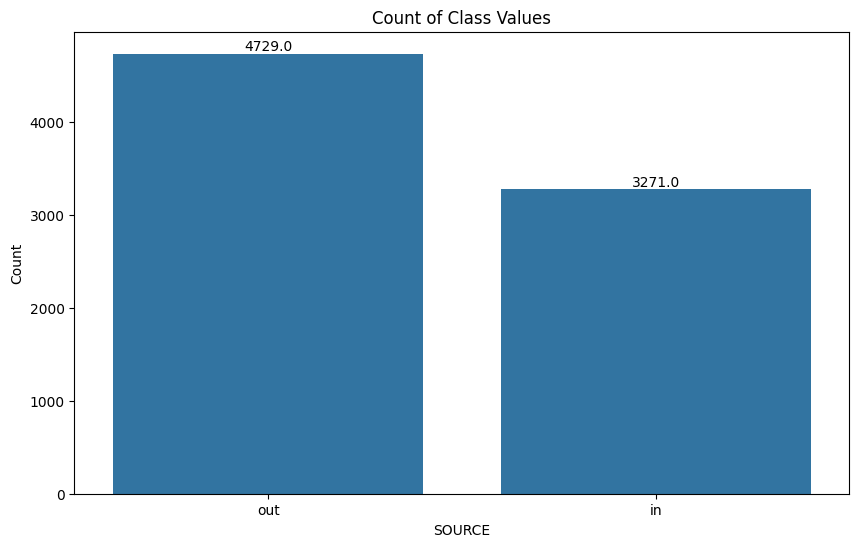

In [5]:
# Create a count plot for the 'Caudal_impulses' column
plt.figure(figsize=(10, 6))
ax = sns.countplot(data=df, x='SOURCE')
plt.xlabel('SOURCE')
plt.ylabel('Count')
plt.title('Count of Class Values')
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', fontsize=10, color='black', xytext=(0, 5),
                textcoords='offset points')
plt.show()

In [6]:
df['SOURCE'].unique()

array(['out', 'in'], dtype=object)

In [7]:
df['AGE'].unique()

array([26, 70, 61, 18, 66, 62, 59,  5, 39, 25, 51, 52, 30, 65, 77, 29, 54,
       45, 56, 27, 41,  7, 60, 43, 32, 36, 63, 67, 73, 23, 58, 22, 50, 10,
       57, 33, 35, 76,  1, 44, 37, 74, 28, 72,  6, 85, 71, 14, 75, 16, 19,
        2, 49,  8, 69, 55, 21, 80, 40, 38, 64, 68, 48, 24, 42, 47, 81, 91,
       84, 53, 11,  3, 31,  9, 12, 83, 34, 87, 20, 78, 79, 88,  4, 82, 46,
       90, 17, 86, 15, 13, 92, 89, 98, 93, 99], dtype=int64)

In [8]:
df.corr(numeric_only=True)

,HAEMATOCRIT,HAEMOGLOBINS,ERYTHROCYTE,LEUCOCYTE,THROMBOCYTE,MCH,MCHC,MCV,AGE
HAEMATOCRIT,1.000000,0.976779,0.871846,-0.233546,-0.005772,0.097090,0.103730,0.071241,-0.247041
HAEMOGLOBINS,0.976779,1.000000,0.824680,-0.219910,-0.043570,0.213831,0.309981,0.115908,-0.231782
ERYTHROCYTE,0.871846,0.824680,1.000000,-0.205426,0.017517,-0.362731,-0.036675,-0.414609,-0.392627
LEUCOCYTE,-0.233546,-0.219910,-0.205426,1.000000,0.257838,-0.000612,0.020760,-0.005622,0.193354
THROMBOCYTE,-0.005772,-0.043570,0.017517,0.257838,1.000000,-0.124867,-0.185154,-0.063590,0.027532
MCH,0.097090,0.213831,-0.362731,-0.000612,-0.124867,1.000000,0.578997,0.927766,0.331381
MCHC,0.103730,0.309981,-0.036675,0.020760,-0.185154,0.578997,1.000000,0.236091,0.038680
MCV,0.071241,0.115908,-0.414609,-0.005622,-0.063590,0.927766,0.236091,1.000000,0.373017
AGE,-0.247041,-0.231782,-0.392627,0.193354,0.027532,0.331381,0.038680,0.373017,1.000000


In [9]:
# Initialize the LabelEncoder
le= LabelEncoder()

# Loop through each column in the DataFrame
for column in df.columns:
    if df[column].dtype == 'object':
        df[column] = le.fit_transform(df[column])
df.head()

,HAEMATOCRIT,HAEMOGLOBINS,ERYTHROCYTE,LEUCOCYTE,THROMBOCYTE,MCH,MCHC,MCV,AGE,SEX,SOURCE
0,47.5,16.6,5.84,7.4,244,28.4,34.9,81.3,26,1,1
1,38.8,12.9,4.54,8.6,223,28.4,33.2,85.5,70,1,0
2,47.0,16.0,5.31,5.0,238,30.1,34.0,88.5,61,1,1
3,35.4,11.9,4.44,2.1,187,26.8,33.6,79.7,18,0,0
4,30.8,11.5,4.05,34.9,523,28.4,37.3,76.0,66,1,1


## Data Splitting

In [10]:
X = df.drop(columns=['SOURCE'])
y=df['SOURCE']

In [11]:
X_train,X_test,y_train,y_test= train_test_split(X,y,test_size=0.2,random_state=42)

In [12]:
labels=['yes','no']

In [13]:
#defining global variables to store accuracy and other metrics
precision = []
recall = []
fscore = []
accuracy = []

In [14]:
#function to calculate various metrics such as accuracy, precision etc
def calculateMetrics(algorithm, testY,predict):
    testY = testY.astype('int')
    predict = predict.astype('int')
    p = precision_score(testY, predict,average='macro') * 100
    r = recall_score(testY, predict,average='macro') * 100
    f = f1_score(testY, predict,average='macro') * 100
    a = accuracy_score(testY,predict)*100 
    accuracy.append(a)
    precision.append(p)
    recall.append(r)
    fscore.append(f)
    print(algorithm+' Accuracy    : '+str(a))
    print(algorithm+' Precision   : '+str(p))
    print(algorithm+' Recall      : '+str(r))
    print(algorithm+' FSCORE      : '+str(f))
    report=classification_report(predict, testY,target_names=labels)
    print('\n',algorithm+" classification report\n",report)
    conf_matrix = confusion_matrix(testY, predict) 
    plt.figure(figsize =(5, 5)) 
    ax = sns.heatmap(conf_matrix, xticklabels = labels, yticklabels = labels, annot = True, cmap="Blues" ,fmt ="g");
    ax.set_ylim([0,len(labels)])
    plt.title(algorithm+" Confusion matrix") 
    plt.ylabel('True class') 
    plt.xlabel('Predicted class') 
    plt.show()

## Decision Tree

Model loaded successfully.
DecisionTreeClassifier Accuracy    : 72.875
DecisionTreeClassifier Precision   : 69.93204431723036
DecisionTreeClassifier Recall      : 72.48281365536529
DecisionTreeClassifier FSCORE      : 70.43093169817749

 DecisionTreeClassifier classification report
               precision    recall  f1-score   support

         yes       0.71      0.55      0.62       646
          no       0.74      0.85      0.79       954

    accuracy                           0.73      1600
   macro avg       0.72      0.70      0.70      1600
weighted avg       0.73      0.73      0.72      1600



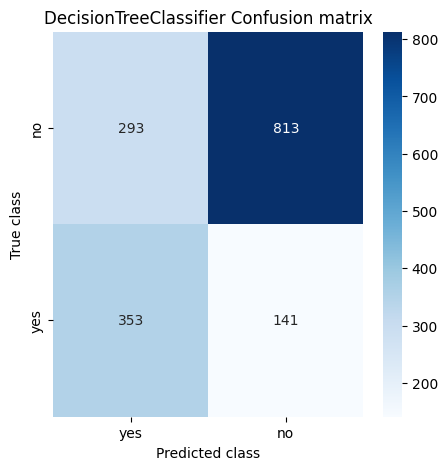

In [15]:
from sklearn.tree import DecisionTreeClassifier
import joblib
import os

if os.path.exists('model2/DecisionTreeClassifier.pkl'):
    # Load the trained model from the file
    DTC = joblib.load('model2/DecisionTreeClassifier.pkl')
    print("Model loaded successfully.")
    predict = DTC.predict(X_test)
    calculateMetrics("DecisionTreeClassifier", predict, y_test)
else:
    # Train the model (assuming X_train and y_train are defined)
    DTC = DecisionTreeClassifier(max_depth=4)
    DTC.fit(X_train, y_train)
    # Save the trained model to a file
    joblib.dump(DTC, 'model2/DecisionTreeClassifier.pkl')
    print("Model saved successfully.")
    predict = DTC.predict(X_test)
    calculateMetrics("DecisionTreeClassifier", predict, y_test)


## Logistic Regression

Logistic Regression model loaded successfully.
LogisticRegression Accuracy    : 71.4375
LogisticRegression Precision   : 67.85199680666706
LogisticRegression Recall      : 71.34670570498902
LogisticRegression FSCORE      : 68.24943301008142

 LogisticRegression classification report
               precision    recall  f1-score   support

         yes       0.71      0.49      0.58       646
          no       0.72      0.86      0.78       954

    accuracy                           0.71      1600
   macro avg       0.71      0.68      0.68      1600
weighted avg       0.71      0.71      0.70      1600



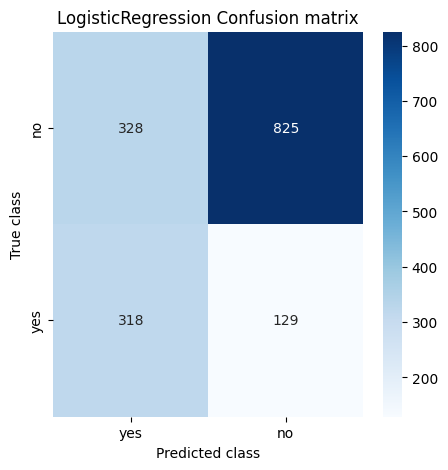

In [16]:
from sklearn.linear_model import LogisticRegression
import joblib
import os

if os.path.exists('model2/LogisticRegression.pkl'):
    # Load the trained model from the file
    LRC = joblib.load('model2/LogisticRegression.pkl')
    print("Logistic Regression model loaded successfully.")
    predict = LRC.predict(X_test)
    calculateMetrics("LogisticRegression", predict, y_test)
else:
    # Train the model
    LRC = LogisticRegression(max_iter=1000)
    LRC.fit(X_train, y_train)
    # Save the trained model to a file
    joblib.dump(LRC, 'model2/LogisticRegression.pkl')
    print("Logistic Regression model saved successfully.")
    predict = LRC.predict(X_test)
    calculateMetrics("LogisticRegression", predict, y_test)


## Support Vector Classifier

SVM model loaded successfully.
SVM Accuracy    : 71.5
SVM Precision   : 67.8794192287971
SVM Recall      : 71.46809439196983
SVM FSCORE      : 68.27688160354799

 SVM classification report
               precision    recall  f1-score   support

         yes       0.71      0.49      0.58       646
          no       0.72      0.87      0.78       954

    accuracy                           0.71      1600
   macro avg       0.71      0.68      0.68      1600
weighted avg       0.71      0.71      0.70      1600



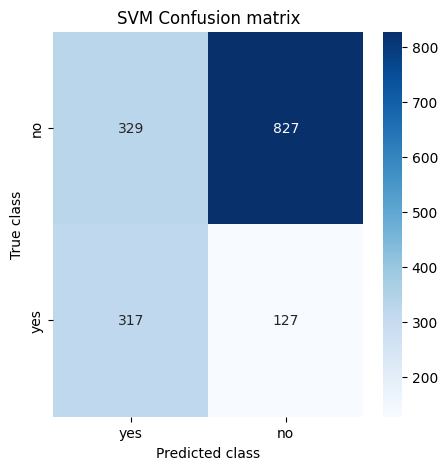

In [17]:
from sklearn.svm import SVC
import joblib
import os

if os.path.exists('model2/SVM.pkl'):
    # Load the trained model from the file
    SVM = joblib.load('model2/SVM.pkl')
    print("SVM model loaded successfully.")
    predict = SVM.predict(X_test)
    calculateMetrics("SVM", predict, y_test)
else:
    # Train the model
    SVM = SVC(kernel='linear')
    SVM.fit(X_train, y_train)
    # Save the trained model to a file
    joblib.dump(SVM, 'model2/SVM.pkl')
    print("SVM model saved successfully.")
    predict = SVM.predict(X_test)
    calculateMetrics("SVM", predict, y_test)


## Navie Bayes Classifier

Naive Bayes model loaded successfully.
NaiveBayes Accuracy    : 67.4375
NaiveBayes Precision   : 63.74804473262326
NaiveBayes Recall      : 66.35028242046009
NaiveBayes FSCORE      : 63.86635231780272

 NaiveBayes classification report
               precision    recall  f1-score   support

         yes       0.64      0.45      0.53       646
          no       0.69      0.83      0.75       954

    accuracy                           0.67      1600
   macro avg       0.66      0.64      0.64      1600
weighted avg       0.67      0.67      0.66      1600



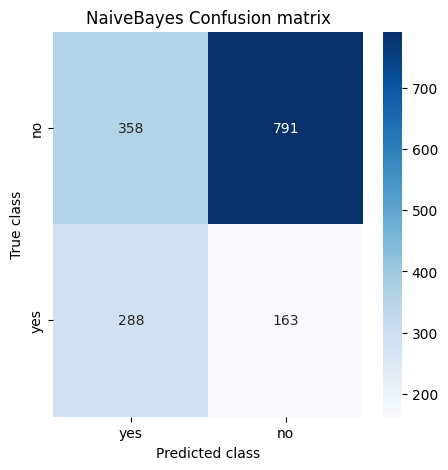

In [18]:
from sklearn.naive_bayes import GaussianNB
import joblib
import os

# Check if the model file exists
if os.path.exists('model2/NaiveBayes.pkl'):
    # Load the trained model from the file
    NB = joblib.load('model2/NaiveBayes.pkl')
    print("Naive Bayes model loaded successfully.")
    predict = NB.predict(X_test)
    calculateMetrics("NaiveBayes", predict, y_test)
else:
    # Train the model
    NB = GaussianNB()
    NB.fit(X_train, y_train)
    # Save the trained model to a file
    joblib.dump(NB, 'model2/NaiveBayes.pkl')
    print("Naive Bayes model saved successfully.")
    predict = NB.predict(X_test)
    calculateMetrics("NaiveBayes", predict, y_test)


Random Forest Classifier

Random Forest model loaded successfully.
RandomForestClassifier Accuracy    : 94.75
RandomForestClassifier Precision   : 94.12316399582011
RandomForestClassifier Recall      : 94.97168638035511
RandomForestClassifier FSCORE      : 94.4986484030526

 RandomForestClassifier classification report
               precision    recall  f1-score   support

         yes       0.96      0.91      0.93       646
          no       0.94      0.97      0.96       954

    accuracy                           0.95      1600
   macro avg       0.95      0.94      0.94      1600
weighted avg       0.95      0.95      0.95      1600



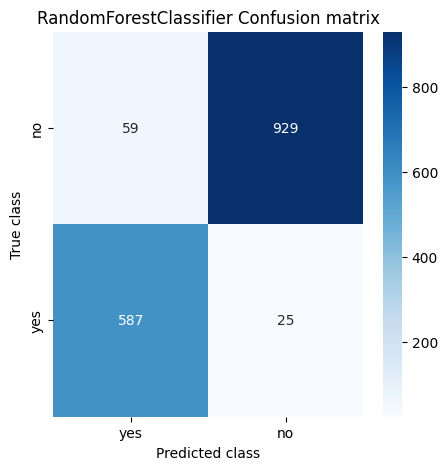

In [19]:
from sklearn.ensemble import RandomForestClassifier
import joblib
import os

if os.path.exists('model2/RandomForestClassifier.pkl'):
    # Load the trained model from the file
    RFC = joblib.load('model2/RandomForestClassifier.pkl')
    print("Random Forest model loaded successfully.")
    predict = RFC.predict(X_test)
    calculateMetrics("RandomForestClassifier", predict, y_test)
else:
    # Train the model
    RFC = RandomForestClassifier(n_estimators=300, max_depth=18, random_state=42)
    RFC.fit(X_train, y_train)
    # Save the trained model to a file
    joblib.dump(RFC, 'model2/RandomForestClassifier.pkl')
    print("Random Forest model saved successfully.")
    predict = RFC.predict(X_test)
    calculateMetrics("RandomForestClassifier", predict, y_test)


## Predict

In [20]:
test=pd.read_csv(r'Dataset/test.csv')
test

,HAEMATOCRIT,HAEMOGLOBINS,ERYTHROCYTE,LEUCOCYTE,THROMBOCYTE,MCH,MCHC,MCV,AGE,SEX
0,47.5,16.6,5.84,7.4,244,28.4,34.9,81.3,26,M
1,38.8,12.9,4.54,8.6,223,28.4,33.2,85.5,70,M
2,47.0,16.0,5.31,5.0,238,30.1,34.0,88.5,61,M
3,35.4,11.9,4.44,2.1,187,26.8,33.6,79.7,18,F
4,30.8,11.5,4.05,34.9,523,28.4,37.3,76.0,66,M
...,...,...,...,...,...,...,...,...,...,...
94,38.0,12.5,4.26,5.7,211,29.3,32.9,89.2,19,F
95,35.2,12.2,3.88,8.7,196,31.4,34.7,90.7,26,F
96,38.8,13.5,5.07,6.3,187,26.6,34.8,76.5,8,M
97,29.7,10.0,3.57,31.6,121,28.0,33.7,83.2,35,F


In [21]:
from sklearn.preprocessing import LabelEncoder

# Initialize the LabelEncoder
label_encoder = LabelEncoder()

# Apply label encoding to the 'SEX' column
test['SEX'] = label_encoder.fit_transform(test['SEX'])

In [22]:
test.head()

,HAEMATOCRIT,HAEMOGLOBINS,ERYTHROCYTE,LEUCOCYTE,THROMBOCYTE,MCH,MCHC,MCV,AGE,SEX
0,47.5,16.6,5.84,7.4,244,28.4,34.9,81.3,26,1
1,38.8,12.9,4.54,8.6,223,28.4,33.2,85.5,70,1
2,47.0,16.0,5.31,5.0,238,30.1,34.0,88.5,61,1
3,35.4,11.9,4.44,2.1,187,26.8,33.6,79.7,18,0
4,30.8,11.5,4.05,34.9,523,28.4,37.3,76.0,66,1


In [23]:
predict = RFC.predict(X_test)
predict

array([0, 0, 1, ..., 1, 1, 1])

In [24]:
# Adjust the loop to avoid index out-of-bounds
for i in range(min(len(predict), test.shape[0])):
    if predict[i] == 0:
        print(test.iloc[i])  # Print the row where prediction is failure
        print("Row {}:************************************************** in".format(i))
    else:
        print(test.iloc[i])  # Print the row where prediction is no failure
        print("Row {}:************************************************** out".format(i))


HAEMATOCRIT      47.50
HAEMOGLOBINS     16.60
ERYTHROCYTE       5.84
LEUCOCYTE         7.40
THROMBOCYTE     244.00
MCH              28.40
MCHC             34.90
MCV              81.30
AGE              26.00
SEX               1.00
Name: 0, dtype: float64
Row 0:************************************************** in
HAEMATOCRIT      38.80
HAEMOGLOBINS     12.90
ERYTHROCYTE       4.54
LEUCOCYTE         8.60
THROMBOCYTE     223.00
MCH              28.40
MCHC             33.20
MCV              85.50
AGE              70.00
SEX               1.00
Name: 1, dtype: float64
Row 1:************************************************** in
HAEMATOCRIT      47.00
HAEMOGLOBINS     16.00
ERYTHROCYTE       5.31
LEUCOCYTE         5.00
THROMBOCYTE     238.00
MCH              30.10
MCHC             34.00
MCV              88.50
AGE              61.00
SEX               1.00
Name: 2, dtype: float64
Row 2:************************************************** out
HAEMATOCRIT      35.40
HAEMOGLOBINS     11.90
ERYTHROCYTE

In [25]:
df['SOURCE'].value_counts()

1    4729
0    3271
Name: SOURCE, dtype: int64

In [26]:
print(df.columns)

Index(['HAEMATOCRIT', 'HAEMOGLOBINS', 'ERYTHROCYTE', 'LEUCOCYTE',
       'THROMBOCYTE', 'MCH', 'MCHC', 'MCV', 'AGE', 'SEX', 'SOURCE'],
      dtype='object')


In [27]:
print(X.columns)


Index(['HAEMATOCRIT', 'HAEMOGLOBINS', 'ERYTHROCYTE', 'LEUCOCYTE',
       'THROMBOCYTE', 'MCH', 'MCHC', 'MCV', 'AGE', 'SEX'],
      dtype='object')


In [28]:
print(df["SEX"].value_counts())

1    4129
0    3871
Name: SEX, dtype: int64


In [29]:
sample = pd.DataFrame([[40,14,4.8,7,250,30,34,90,30,1]], columns=X.columns)
print(RFC.predict(sample))

[1]


In [30]:
df.groupby("SOURCE").mean()

,HAEMATOCRIT,HAEMOGLOBINS,ERYTHROCYTE,LEUCOCYTE,THROMBOCYTE,MCH,MCHC,MCV,AGE,SEX
SOURCE,,,,,,,,,,
0,36.276735,12.120422,4.325830,9.693091,221.815653,28.209447,33.395353,84.417548,49.603791,0.558545
1,39.381222,13.141975,4.661286,8.212222,280.276168,28.344724,33.345612,84.938211,44.989004,0.486784


In [31]:
from sklearn.metrics import accuracy_score

print("RF:", accuracy_score(y_test, RFC.predict(X_test)))
print("DT:", accuracy_score(y_test, DTC.predict(X_test)))
print("LR:", accuracy_score(y_test, LRC.predict(X_test)))
print("NB:", accuracy_score(y_test, NB.predict(X_test)))
print("SVM:", accuracy_score(y_test, SVM.predict(X_test)))

RF: 0.9475
DT: 0.72875
LR: 0.714375
NB: 0.674375
SVM: 0.715


In [32]:
df[df["SOURCE"] == 0].sample(5)

,HAEMATOCRIT,HAEMOGLOBINS,ERYTHROCYTE,LEUCOCYTE,THROMBOCYTE,MCH,MCHC,MCV,AGE,SEX,SOURCE
2612,37.7,11.8,4.20,12.4,354,28.1,31.3,89.8,51,0,0
5268,33.5,10.7,4.24,9.5,240,25.2,31.9,79.0,46,0,0
7395,26.5,8.9,2.77,6.8,247,32.1,33.6,95.7,72,1,0
6129,41.9,14.1,4.59,6.7,283,30.7,33.7,91.3,65,1,0
3929,34.0,11.3,4.06,10.3,352,27.8,33.2,83.7,53,0,0


In [33]:
df[df["SOURCE"] == 1].sample(5)

,HAEMATOCRIT,HAEMOGLOBINS,ERYTHROCYTE,LEUCOCYTE,THROMBOCYTE,MCH,MCHC,MCV,AGE,SEX,SOURCE
5999,56.3,18.2,7.48,6.1,150,24.3,32.3,75.3,63,1,1
6714,41.3,14.1,4.66,7.6,251,30.3,34.1,88.6,64,1,1
2232,35.7,11.9,4.11,6.6,247,29.0,33.3,86.9,29,0,1
2845,40.7,13.7,4.73,9.4,372,29.0,33.7,86.0,57,0,1
3727,38.9,12.5,4.30,6.4,318,29.1,32.1,90.5,67,0,1
